# Amazon Fashion Products — EDA

Dataset: `marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson`  
30,000 fashion products from Amazon India (Feb–Apr 2020).

Goal of this notebook: understand the columns, the missing data, and which fields
are worth using for a product similarity search. Decisions are written up in `notes.md`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = 'data/marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson'
df = pd.read_json(path, lines=True)
df.shape

(30000, 33)

In [14]:
df.head()

,uniq_id,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,...,colour,no__of_reviews,seller_name,seller_id,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books
0,26d41bdc1495de290bc8e6062d927729,2020-02-07 05:11:36 +0000,B07STS2W9T,https://www.amazon.in/Facon-Kalamkari-Handbloc...,LA' Facon Cotton Kalamkari Handblock Saree Blo...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968255e+09,LA' Facon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,410c62298852e68f34c35560f2311e5a,2020-02-07 08:45:56 +0000,B07N6TD2WL,https://www.amazon.in/Sf-Jeans-Pantaloons-T-Sh...,Sf Jeans By Pantaloons Men's Plain Slim fit T-...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,52e31bb31680b0ec73de0d781a23cc0a,2020-02-06 11:09:38 +0000,B07WJ6WPN1,https://www.amazon.in/LOVISTA-Traditional-Prin...,LOVISTA Cotton Gota Patti Tassel Traditional P...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968255e+09,LOVISTA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25798d6dc43239c118452d1bee0fb088,2020-02-07 08:32:45 +0000,B07PYSF4WZ,https://www.amazon.in/People-Printed-Regular-T...,People Men's Printed Regular fit T-Shirt,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ad8a5a196d515ef09dfdaf082bdc37c4,2020-02-06 14:27:48 +0000,B082KXNM7X,https://www.amazon.in/Monte-Carlo-Cotton-Colla...,Monte Carlo Grey Solid Cotton Blend Polo Colla...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968070e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing values

First thing I want to know: how complete is each column?

In [15]:
fill = (df.notna().mean() * 100).round(1).sort_values()
fill

name_of_author_for_books           0.0
formats___editions                 0.0
no__of_sellers                     3.4
no__of_offers                      3.4
technical_details__k_v_pairs       3.8
left_in_stock                     10.2
no__of_reviews                    11.5
colour                            20.1
seller_id                         27.9
seller_name                       27.9
discount_percentage               48.7
brand                             72.9
other_items_customers_buy         81.2
sales_rank_in_child_category      82.8
parent___child_category__all      85.0
sales_rank_in_parent_category     85.0
sales_price                       90.4
large                             96.1
product_details__k_v_pairs        96.1
browsenode                        98.3
uniq_id                          100.0
amazon_prime__y_or_n             100.0
delivery_type                    100.0
rating                           100.0
weight                           100.0
medium                   

Lots of near-empty columns (`name_of_author_for_books`, `formats___editions`, the seller
fields, `colour`). `weight` is fully populated but I want to check the values - it looks
like a placeholder.

In [16]:
df['weight'].value_counts().head()

weight
999999999    23745
200 g          736
249 g          689
299 g          398
399 g          304
Name: count, dtype: int64

About 79% of weights are the sentinel `999999999`; the rest are strings like `200 g`. Too sparse and messy to rely on, so I drop it.

## Numeric fields: price, rating, discount

`sales_price` and `discount_percentage` come in as strings with `₹`/`%`, so I parse them
into plain numbers first (without touching `df`).

In [17]:
price = pd.to_numeric(df['sales_price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
rating = pd.to_numeric(df['rating'], errors='coerce')
discount = pd.to_numeric(df['discount_percentage'].astype(str).str.rstrip('%'), errors='coerce')

pd.DataFrame({'price': price, 'rating': rating, 'discount': discount}).describe().round(1)

,price,rating,discount
count,27110.0,30000.0,14624.0
mean,862.2,4.0,51.8
std,964.2,0.8,18.8
min,39.0,1.0,1.0
25%,379.0,3.5,40.0
50%,590.0,4.0,54.0
75%,899.0,4.9,65.0
max,9988.0,5.0,99.0


skew raw: 3.8  | skew log: 0.8


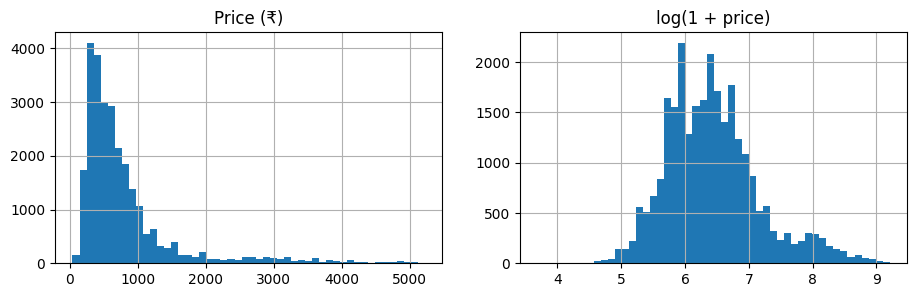

In [18]:
# price is very right-skewed, so look at it raw and log-scaled
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
price[price < price.quantile(0.99)].hist(bins=50, ax=ax[0])
ax[0].set_title('Price (₹)')
np.log1p(price).hist(bins=50, ax=ax[1])
ax[1].set_title('log(1 + price)')
print('skew raw:', round(price.skew(), 1), ' | skew log:', round(np.log1p(price).skew(), 1))

mean rating: 4.04


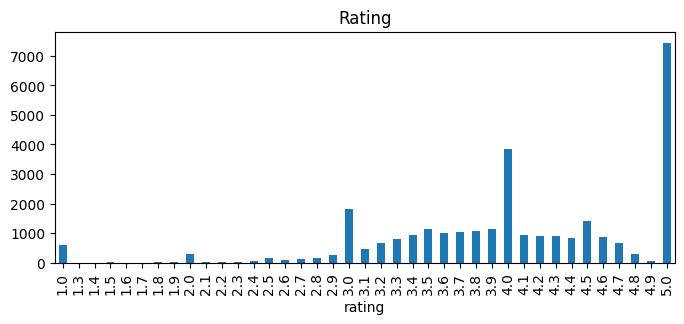

In [19]:
rating.value_counts().sort_index().plot(kind='bar', figsize=(8, 3), title='Rating')
print('mean rating:', round(rating.mean(), 2))

Ratings pile up on whole/half values (4.0, 4.5, 5.0) and most products sit at 4+. Discount
is only filled for ~49% of rows - a null there just means the product isn't discounted.

## Categories and brands

Category lives inside `sales_rank_in_child_category` as a `{category: rank}` dict, so I pull the key out.

unique categories: 218


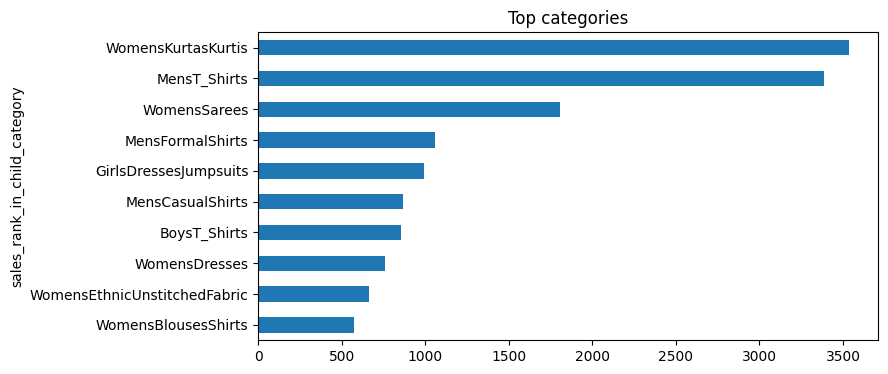

In [20]:
category = df['sales_rank_in_child_category'].apply(lambda v: list(v)[0] if isinstance(v, dict) else None)
print('unique categories:', category.nunique())
category.value_counts().head(10).plot(kind='barh', figsize=(8, 4), title='Top categories').invert_yaxis()

brand missing: 8143


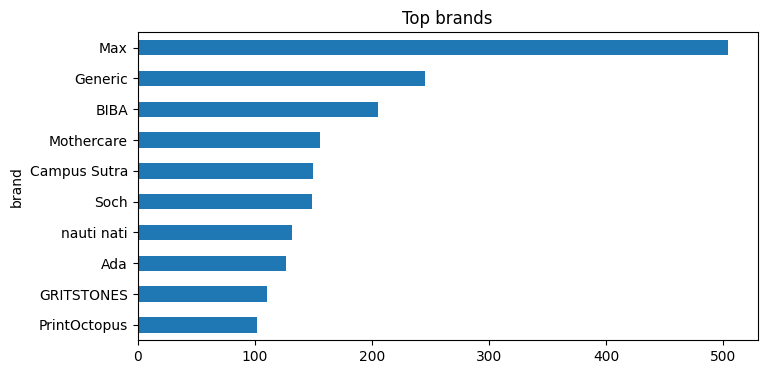

In [21]:
print('brand missing:', df['brand'].isna().sum())
df['brand'].value_counts().head(10).plot(kind='barh', figsize=(8, 4), title='Top brands').invert_yaxis()

Women's kurtas, men's t-shirts and sarees dominate. Brands are long-tailed and ~27% of
products have no brand at all.

## Does Prime / delivery type relate to price?

In [22]:
print(price.groupby(df['delivery_type']).median())
print()
print(price.groupby(df['amazon_prime__y_or_n']).median())

delivery_type
fulfilled_by_amazon      579.0
fulfilled_by_merchant    590.5
Name: sales_price, dtype: float64

amazon_prime__y_or_n
N    399.0
Y    699.0
Name: sales_price, dtype: float64


Delivery type barely moves the price, but Prime products are clearly pricier - that's a
more useful signal than delivery type.

## Correlations between the numeric fields

In [23]:
pd.DataFrame({'price': price, 'rating': rating, 'discount': discount}).corr().round(2)

,price,rating,discount
price,1.00,0.09,-0.36
rating,0.09,1.00,-0.12
discount,-0.36,-0.12,1.00


Rating is basically uncorrelated with price. Discount and price are mildly negative
(pricier items discount less). Nothing strong enough to drop a feature for redundancy.

## Cleaning & feature-engineering checks

A few checks that decide *how* I'd clean and encode each field for the similarity model.

In [24]:
# how many unique values? -> tells me how to encode each categorical
for c in ['brand', 'browsenode']:
    print(f'{c:10s} ->', df[c].nunique(), 'unique')
print(f'{"category":10s} ->', category.nunique(), 'unique')

brand      -> 6458 unique
browsenode -> 302 unique
category   -> 218 unique


`brand` is very high-cardinality (~6.5k) so one-hot is out - label-encode or hash it. `category` (218) and `browsenode` (302) are small enough to encode directly.

In [25]:
# any repeated products? uniq_id should be unique; asin can repeat (re-crawls)
print('duplicate uniq_id:', df['uniq_id'].duplicated().sum())
print('duplicate asin   :', df['asin'].duplicated().sum())

duplicate uniq_id: 0
duplicate asin   : 471


`uniq_id` is unique but ~471 `asin`s repeat - I'd drop asin duplicates before building the index so the same product doesn't show up twice in results.

In [26]:
# what do the text fields look like? these feed the text embedding
print('product_name length:', df['product_name'].str.len().describe()[['mean','min','max']].round(0).to_dict())
print('meta_keywords filled  :', round(df['meta_keywords'].notna().mean(), 2))
print('product_details filled:', round(df['product_details__k_v_pairs'].notna().mean(), 2))
df['product_name'].head(3).tolist()

product_name length: {'mean': 58.0, 'min': 4.0, 'max': 500.0}
meta_keywords filled  : 1.0
product_details filled: 0.96


["LA' Facon Cotton Kalamkari Handblock Saree Blouse Fabric 100 cms Black Base Dancers (Cotton)",
 "Sf Jeans By Pantaloons Men's Plain Slim fit T-Shirt",
 'LOVISTA Cotton Gota Patti Tassel Traditional Printed Kurti with Pant,Angrakha Salwar Suit']

`product_name` is short (~58 chars) but always present, and `meta_keywords` / `product_details` are nearly complete - good material for a text embedding.

In [27]:
# preview category-median price imputation (NOT applied to df - just checking coverage)
cat_median = price.groupby(category).transform('median')
filled = price.fillna(cat_median)
print('missing prices before:', price.isna().sum(), '-> after:', filled.isna().sum())

missing prices before: 2890 -> after: 2040


Category-median fills most of the missing prices but ~850 remain (categories where every product is unpriced), so I'd add a global-median fallback on top.